# 01 — Data Collection

Pulls Google Trends monthly data for Stack Overflow (treatment) and three developer-ecosystem controls.  
Caches everything to `data/raw/` on first pull — subsequent runs are instant.

**If pytrends rate-limits:** wait 60 s, then re-run the pull cell with `force_pull=False` (cache already exists).

In [1]:
import sys
sys.path.insert(0, '..')   # project root when run from notebooks/
sys.path.insert(0, '.')    # project root when run from repo root

import pandas as pd
from src.data import load_or_pull, process_trends, save_processed
from src.config import ALL_KEYWORDS, INTERVENTION_DATE, START_DATE, END_DATE

print(f"Keywords   : {ALL_KEYWORDS}")
print(f"Date range : {START_DATE}  →  {END_DATE}")
print(f"Intervention date : {INTERVENTION_DATE}")

Keywords   : ['stack overflow', 'github', 'w3schools', 'geeksforgeeks']
Date range : 2018-01-01  →  2026-04-01
Intervention date : 2022-11-01


## 1. Pull (or load from cache)

In [2]:
# force_pull=True  → always re-hit Google Trends (use when data feels stale)
# force_pull=False → use cached CSV if it exists (default, safe for re-runs)
df_raw = load_or_pull(force_pull=False)
df_raw

Loading cached raw data from C:\Users\User\OneDrive\Desktop\Claude\projects\-stackoverflow-chatgpt-causal-impact\notebooks\..\data\raw\trends_raw.csv


,stack overflow,github,w3schools,geeksforgeeks
date,,,,
2018-01-01,41,11,50,45
2018-02-01,42,11,57,43
2018-03-01,38,12,51,46
2018-04-01,36,11,49,45
2018-05-01,37,11,47,45
...,...,...,...,...
2025-12-01,28,59,41,53
2026-01-01,39,58,40,50
2026-02-01,38,68,44,50


## 2. Validate raw data

In [3]:
print(f"Shape      : {df_raw.shape}")
print(f"Date range : {df_raw.index.min().date()}  →  {df_raw.index.max().date()}")
print(f"\nMissing values per column:")
print(df_raw.isna().sum())
print(f"\nDescriptive stats:")
display(df_raw.describe().round(1))

Shape      : (100, 4)
Date range : 2018-01-01  →  2026-04-01

Missing values per column:
stack overflow    0
github            0
w3schools         0
geeksforgeeks     0
dtype: int64

Descriptive stats:


,stack overflow,github,w3schools,geeksforgeeks
count,100.0,100.0,100.0,100.0
mean,33.1,25.0,57.5,63.0
std,10.3,17.2,16.9,14.7
min,17.0,10.0,34.0,42.0
25%,26.0,12.0,44.8,50.0
50%,33.0,23.0,51.5,62.0
75%,38.0,31.2,70.2,71.5
max,100.0,100.0,100.0,100.0


## 3. Process and save

In [4]:
df = process_trends(df_raw)
save_processed(df)

print(f"\nFinal shape       : {df.shape}")
print(f"Pre-intervention  : {(df.index < INTERVENTION_DATE).sum()} months")
print(f"Post-intervention : {(df.index >= INTERVENTION_DATE).sum()} months")

Saved processed data → C:\Users\User\OneDrive\Desktop\Claude\projects\-stackoverflow-chatgpt-causal-impact\notebooks\..\data\processed\trends_processed.csv

Final shape       : (100, 4)
Pre-intervention  : 58 months
Post-intervention : 42 months


## 4. Quick sanity plot

All four series on the same axes. Red dashed line = ChatGPT launch.  
Values are 0–100, relative to the highest point within this single request — so all series are directly comparable.

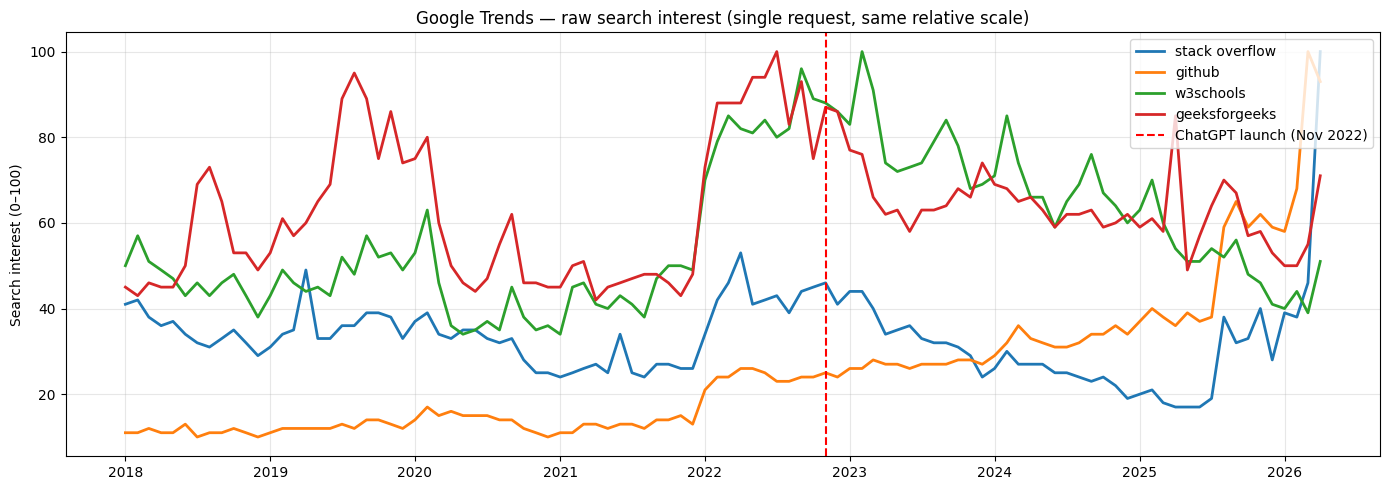

Plot saved to data/processed/sanity_plot.png


In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

for col in df.columns:
    ax.plot(df.index, df[col], label=col, linewidth=2)

ax.axvline(pd.Timestamp(INTERVENTION_DATE), color='red',
           linestyle='--', linewidth=1.5, label='ChatGPT launch (Nov 2022)')

ax.set_title('Google Trends — raw search interest (single request, same relative scale)')
ax.set_ylabel('Search interest (0–100)')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/sanity_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to data/processed/sanity_plot.png")